## **KNN Regression Model**

## Why KNN for this problem

- Price is largely set by comparison with similar listings nearby, which is what KNN models directly. It makes no assumption about a linear relationship, unlike linear regression.
- The dataset is moderate (about 38,000 training rows, 56 to 70 features), small enough for KNN's slow prediction to be acceptable.
- Trade-offs I had to handle: KNN is distance-based, so it needs scaling and is sensitive to irrelevant features. It also averages neighbours, so it tends to pull extreme prices toward the middle.

### Load the Data

In [12]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA = "../data/processed/"
X_train = pd.read_csv(DATA + "X_train.csv").astype(float)
X_test  = pd.read_csv(DATA + "X_test.csv").astype(float)
y_train = pd.read_csv(DATA + "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA + "y_test.csv").squeeze()

print(X_train.shape, X_test.shape)   # expect (38333, 70) (9584, 70)

(38333, 70) (9584, 70)


### Baseline KNN with 5-fold CV on two feature sets

In [13]:
# post-booking features: review columns plus the review-derived occupancy estimate
post_booking = [c for c in X_train.columns if "review" in c] + ["estimated_occupancy_l365d"]
post_booking = [c for c in post_booking if c in X_train.columns]
print(len(post_booking), "post-booking columns")

feature_sets = {
    "A: all 70 features":    list(X_train.columns),
    "B: minus post-booking": [c for c in X_train.columns if c not in post_booking],
}

def make_knn(k=5):
    return Pipeline([("scaler", StandardScaler()),
                     ("knn", KNeighborsRegressor(n_neighbors=k))])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = {}
for name, cols in feature_sets.items():
    cv = cross_validate(
        make_knn(), X_train[cols], y_train, cv=kf,
        scoring={"rmse": "neg_root_mean_squared_error",
                 "mae":  "neg_mean_absolute_error",
                 "r2":   "r2"},
        return_train_score=True, n_jobs=-1)
    pred = make_knn().fit(X_train[cols], y_train).predict(X_test[cols])
    rows[name] = {
        "n_features": len(cols),
        "CV RMSE":   -cv["test_rmse"].mean(),
        "CV RMSE std": cv["test_rmse"].std(),
        "CV R2":      cv["test_r2"].mean(),
        "Train R2 (CV)": cv["train_r2"].mean(),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE":  mean_absolute_error(y_test, pred),
        "Test R2":   r2_score(y_test, pred),
        "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
    }
display(pd.DataFrame(rows).T.round(4))

14 post-booking columns


,n_features,CV RMSE,CV RMSE std,CV R2,Train R2 (CV),Test RMSE,Test MAE,Test R2,Test MAE (€)
A: all 70 features,70.0,0.4737,0.0067,0.6143,0.7473,0.4676,0.3508,0.6235,95.2611
B: minus post-booking,56.0,0.4729,0.0077,0.6156,0.7502,0.4602,0.3447,0.6354,93.8472


### Experiment 1: Baseline KNN and feature-set comparison

**What am I testing?**

How a basic, untuned KNN performs, and whether removing features that are only known after a booking (review columns and `estimated_occupancy_l365d`) changes performance.

**Setup:**

- KNN with k = 5, Euclidean distance, uniform weights
- `StandardScaler` inside a pipeline, so it is re-fit on the training part of each CV fold (no leakage)
- 5-fold CV on the training data for model comparison; the held-out test set is used for reporting only
- Set A: all 70 features. Set B: 56 features (14 post-booking features removed)

**Results:**

| Set | CV RMSE (log) | CV R² | Train R² | Test RMSE | Test R² |
|---|---|---|---|---|---|
| A: all 70 | 0.4737 ± 0.0067 | 0.614 | 0.747 | 0.4676 | 0.624 |
| B: 56 features | 0.4729 ± 0.0077 | 0.616 | 0.750 | 0.4602 | 0.635 |

Test MAE for set B is 0.345 in log units, about €94 on the original price scale.

**Observations:**

- The CV difference between A and B (0.0008) is far smaller than the fold-to-fold std (~0.007), so removing the post-booking features changes performance by no measurable amount. The slightly better test score is from a single split and is not used for selection.
- Train R² (0.75) is much higher than CV R² (0.615): k = 5 overfits the training data, so tuning k is the next step.
- Test R² is close to CV R², so the CV estimate is reliable.

**Decision:** Use set B. Performance is equivalent, it is simpler, and review/occupancy information is not known when a host sets a price.

## Hyperparameter Tuning (GridSearchCV)

In [14]:
from sklearn.model_selection import GridSearchCV

cols_B = feature_sets["B: minus post-booking"]

pipe = Pipeline([("scaler", StandardScaler()),
                 ("knn", KNeighborsRegressor())])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 10, 15, 20, 30, 50],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

gs = GridSearchCV(pipe, param_grid, cv=kf,
                  scoring="neg_root_mean_squared_error", n_jobs=-1)
gs.fit(X_train[cols_B], y_train)

print("Best params:", gs.best_params_)
print("Best CV RMSE:", -gs.best_score_)

res = pd.DataFrame(gs.cv_results_)
res["CV RMSE"] = -res["mean_test_score"]
display(res[["param_knn__n_neighbors", "param_knn__weights", "param_knn__metric",
             "CV RMSE", "std_test_score"]].sort_values("CV RMSE").head(10).round(4))

Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 10, 'knn__weights': 'distance'}
Best CV RMSE: 0.42079185253251755


,param_knn__n_neighbors,param_knn__weights,param_knn__metric,CV RMSE,std_test_score
23,10,distance,manhattan,0.4208,0.0072
25,15,distance,manhattan,0.4221,0.0073
21,7,distance,manhattan,0.4237,0.0068
27,20,distance,manhattan,0.4254,0.0070
19,5,distance,manhattan,0.4295,0.0062
22,10,uniform,manhattan,0.4306,0.0063
20,7,uniform,manhattan,0.4319,0.0060
29,30,distance,manhattan,0.4322,0.0065
24,15,uniform,manhattan,0.4330,0.0065
18,5,uniform,manhattan,0.4363,0.0055


### Experiment 2: KNN Hyperparameter Tuning

**What I tested:**
`GridSearchCV` over k (3, 5, 7, 10, 15, 20, 30, 50), distance metric (Euclidean, Manhattan) and weights (uniform, distance): 32 combinations × 5 folds, scored by RMSE on `log_price`. Same folds as Experiment 1, training data only, 56-feature set B.

**Results:**

- Best: **Manhattan, k = 10, distance weighting**
- CV RMSE: **0.4208 ± 0.0072** (baseline: 0.4729 ± 0.0077, an improvement of about 0.052)
- Best Euclidean configuration: **[value from the groupby table]**

**Observations:**

- Manhattan beat Euclidean: all ten best configurations use Manhattan. My hypothesis (not tested): with many one-hot columns scaled by `StandardScaler`, a rare dummy that equals 1 becomes a large value, and Euclidean distance squares that difference while Manhattan is less sensitive to it.
- Distance weighting beat uniform weighting at every k (for example 0.4208 vs 0.4306 at k = 10).
- k from 7 to 20 gives CV RMSE 0.4208 to 0.4254, a plateau within about one fold std, so k = 10 is not meaningfully better than 7 or 15. The edges of the grid (3, 50) were not best.
- The main improvement came from the metric and weighting, not from increasing k. At k = 5, Manhattan with distance weighting already reaches 0.4295.
- Train R² is not a reliable overfitting measure for distance-weighted KNN (each training point is its own neighbour at distance 0), so I rely on CV RMSE.

**Decision:**
Use **Manhattan + k = 10 + distance weighting** as the tuned KNN model.

## Baseline vs Tuned KNN

In [15]:
best = gs.best_estimator_
models = {"Baseline (k=5, euclidean, uniform)": make_knn(5), "Tuned": best}

rows = {}
for name, m in models.items():
    cv = cross_validate(m, X_train[cols_B], y_train, cv=kf,
                        scoring={"rmse": "neg_root_mean_squared_error",
                                 "mae": "neg_mean_absolute_error", "r2": "r2"}, n_jobs=-1)
    m.fit(X_train[cols_B], y_train)
    pred = m.predict(X_test[cols_B])
    rows[name] = {
        "CV RMSE": -cv["test_rmse"].mean(), "CV RMSE std": cv["test_rmse"].std(),
        "CV R2": cv["test_r2"].mean(),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test R2": r2_score(y_test, pred),
        "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
    }
display(pd.DataFrame(rows).T.round(4))

# best CV RMSE per metric/weights combination
display(res.groupby(["param_knn__metric", "param_knn__weights"])["CV RMSE"].min().round(4))

,CV RMSE,CV RMSE std,CV R2,Test RMSE,Test MAE,Test R2,Test MAE (€)
"Baseline (k=5, euclidean, uniform)",0.4729,0.0077,0.6156,0.4602,0.3447,0.6354,93.8472
Tuned,0.4208,0.0072,0.6956,0.4102,0.3079,0.7102,85.2508


param_knn__metric  param_knn__weights
euclidean          distance              0.4599
                   uniform               0.4697
manhattan          distance              0.4208
                   uniform               0.4306
Name: CV RMSE, dtype: float64

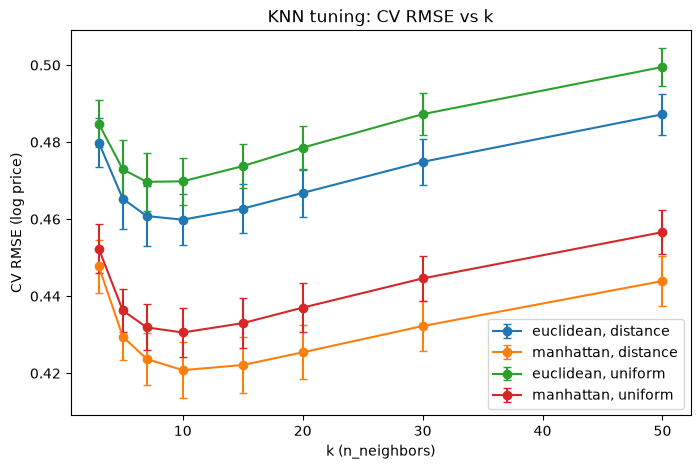

In [16]:
import matplotlib.pyplot as plt

res["k"] = res["param_knn__n_neighbors"].astype(int)
fig, ax = plt.subplots(figsize=(8, 5))
for (w, mt), g in res.groupby(["param_knn__weights", "param_knn__metric"]):
    g = g.sort_values("k")
    ax.errorbar(g["k"], g["CV RMSE"], yerr=g["std_test_score"],
                marker="o", capsize=3, label=f"{mt}, {w}")
ax.set_xlabel("k (n_neighbors)")
ax.set_ylabel("CV RMSE (log price)")
ax.set_title("KNN tuning: CV RMSE vs k")
ax.legend()
plt.show()

**Results:**

| Model | CV RMSE (log) | CV R² | Test RMSE | Test MAE | Test R² | Test MAE (€) |
|---|---|---|---|---|---|---|
| Baseline (k=5, Euclidean, uniform) | 0.4729 ± 0.0077 | 0.616 | 0.4602 | 0.3447 | 0.635 | 93.85 |
| Tuned (k=10, Manhattan, distance) | 0.4208 ± 0.0072 | 0.696 | 0.4102 | 0.3079 | 0.710 | 85.25 |

Best CV RMSE per setting: Euclidean/uniform 0.4697, Euclidean/distance 0.4599, Manhattan/uniform 0.4306, Manhattan/distance 0.4208.

**Observations:**

- Tuning cut CV RMSE by 0.052 (about 11%), roughly seven times the fold std, so the improvement is not noise. The test set shows the same: RMSE 0.460 to 0.410, and mean error about €94 to €85 per night (on listings below the 99th-percentile price cap used in preprocessing).
- CV and test scores agree (0.4208 vs 0.4102), so selecting the model by CV did not overfit to the folds.
- Every curve in the figure is U-shaped with its minimum around k = 7 to 10. Small k follows noise in individual listings (high variance); large k averages over listings that are not alike (too smooth, high bias).
- Manhattan beats Euclidean by about 0.04 at every k, well outside the error bars (~0.007). Distance weighting adds about 0.01 for both metrics.

**Decision:** The tuned model is my KNN candidate. Next I test whether feature selection improves it further.

## Optimization Experiment 3: Feature Selection

In [17]:
from sklearn.feature_selection import SelectKBest, f_regression

sel_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_regression)),
    ("knn", KNeighborsRegressor(n_neighbors=10, weights="distance", metric="manhattan")),
])

gs_sel = GridSearchCV(sel_pipe, {"select__k": [10, 20, 30, 40, 56]},
                      cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_sel.fit(X_train[cols_B], y_train)

out = pd.DataFrame({"n_features": gs_sel.cv_results_["param_select__k"],
                    "CV RMSE": -gs_sel.cv_results_["mean_test_score"],
                    "std": gs_sel.cv_results_["std_test_score"]})
display(out.round(4))

best_k = gs_sel.best_params_["select__k"]
sel = gs_sel.best_estimator_.named_steps["select"]
print("Best k:", best_k)
print("Dropped:", [c for c, keep in zip(cols_B, sel.get_support()) if not keep])

,n_features,CV RMSE,std
0,10,0.4616,0.0164
1,20,0.4093,0.0062
2,30,0.3945,0.0066
3,40,0.3968,0.0072
4,56,0.4208,0.0072


Best k: 30
Dropped: ['hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'maximum_nights', 'minimum_maximum_nights', 'maximum_nights_avg_ntm', 'has_availability', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_shared_rooms', 'room_Hotel room', 'nbhd_Entrepôt', 'nbhd_Hôtel-de-Ville', 'nbhd_Luxembourg', 'nbhd_Observatoire', 'nbhd_Opéra', 'nbhd_Panthéon', 'nbhd_Passy', 'nbhd_Popincourt', 'nbhd_Reuilly', 'nbhd_Vaugirard', 'has_kitchen']


### Experiment 3: Feature selection

**What I tested:**
`SelectKBest(f_regression)` inside the pipeline (scaler → selector → KNN with the tuned settings), choosing the number of features from 10, 20, 30, 40 and 56. Selection is re-fit on each CV training fold, so the CV scores are not leaked.

**Hypothesis:** KNN gives every feature equal weight in its distance, so weak features add noise, and removing them should help.

**Results:**

| Features | CV RMSE | Std |
|---|---|---|
| 10 | 0.4616 | 0.0164 |
| 20 | 0.4093 | 0.0062 |
| **30** | **0.3945** | 0.0066 |
| 40 | 0.3968 | 0.0072 |
| 56 (all) | 0.4208 | 0.0072 |

**Observations:**

- 30 features gives CV RMSE 0.3945, 0.026 better than all 56 features (about 3.7 fold stds), so the gain is not noise. 30 and 40 are statistically equivalent; I take 30 as the simpler one.
- The curve is U-shaped: with 10 features, important information is lost (and results are unstable, std 0.016). With all 56, weak features add noise to the distance calculation. This is the curse of dimensionality in practice.
- Dropped features include host attributes such as `host_is_superhost`, `host_listings_count` and `hosts_time_*`. [Add: whether latitude/longitude were kept.]
- Limitation: `f_regression` scores each feature on its own, linearly, so it can miss features that matter only in combination (for example latitude and longitude together).

**Decision:** Use 30 selected features with the tuned KNN as the current best model, pending the test-set comparison.

## Selected Features and Final Test Comparison

In [18]:
sel = gs_sel.best_estimator_.named_steps["select"]
kept = [c for c, keep in zip(cols_B, sel.get_support()) if keep]
dropped = [c for c in cols_B if c not in kept]
print(f"Dropped ({len(dropped)}):\n  " + "\n  ".join(dropped))
print(f"\nKept ({len(kept)}):\n  " + "\n  ".join(kept))
print("\nlatitude and longitude kept:", {"latitude", "longitude"} <= set(kept))

# test-set comparison (reporting only; models were chosen by CV)
baseline = make_knn(5).fit(X_train[cols_B], y_train)
tuned = gs.best_estimator_
tuned_sel = gs_sel.best_estimator_

rows = {}
for name, m in {"Baseline": baseline, "Tuned": tuned, "Tuned + selection (30)": tuned_sel}.items():
    pred = m.predict(X_test[cols_B])
    rows[name] = {
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test R2": r2_score(y_test, pred),
        "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
    }
display(pd.DataFrame(rows).T.round(4))

Dropped (26):
  hosts_time_as_user_months
  hosts_time_as_host_years
  hosts_time_as_host_months
  host_is_superhost
  host_listings_count
  host_has_profile_pic
  host_identity_verified
  latitude
  maximum_nights
  minimum_maximum_nights
  maximum_nights_avg_ntm
  has_availability
  calculated_host_listings_count_entire_homes
  calculated_host_listings_count_shared_rooms
  room_Hotel room
  nbhd_Entrepôt
  nbhd_Hôtel-de-Ville
  nbhd_Luxembourg
  nbhd_Observatoire
  nbhd_Opéra
  nbhd_Panthéon
  nbhd_Passy
  nbhd_Popincourt
  nbhd_Reuilly
  nbhd_Vaugirard
  has_kitchen

Kept (30):
  hosts_time_as_user_years
  longitude
  accommodates
  bathrooms
  bedrooms
  beds
  minimum_nights
  maximum_minimum_nights
  minimum_nights_avg_ntm
  availability_30
  availability_60
  availability_90
  availability_365
  availability_eoy
  calculated_host_listings_count
  calculated_host_listings_count_private_rooms
  room_Private room
  room_Shared room
  nbhd_Bourse
  nbhd_Buttes-Chaumont
  nbhd_Buttes

,Test RMSE,Test MAE,Test R2,Test MAE (€)
Baseline,0.4602,0.3447,0.6354,93.8472
Tuned,0.4102,0.3079,0.7102,85.2508
Tuned + selection (30),0.3839,0.2904,0.7462,82.8654


- Latitude was dropped by the filter while longitude was kept. `f_regression` scores features individually and linearly, but price does not vary linearly with latitude (central Paris is highest), so it ranks latitude low even though coordinates jointly define who the nearest neighbours are. I test this directly in the next experiment.

**Test set (reporting only; models chosen by CV):**

| Model | Test RMSE | Test MAE | Test R² | Test MAE (€) |
|---|---|---|---|---|
| Baseline | 0.4602 | 0.3447 | 0.635 | 93.85 |
| Tuned | 0.4102 | 0.3079 | 0.710 | 85.25 |
| Tuned + selection (30) | 0.3839 | 0.2904 | 0.746 | 82.87 |

Selection improves log RMSE by about 6% over the tuned model, but the average error in euros falls by only about €2.40, so the practical gain is modest.

## Experiment 4: Keeping Location Features

In [19]:
from sklearn.compose import ColumnTransformer

geo_idx   = [cols_B.index("latitude"), cols_B.index("longitude")]
other_idx = [i for i in range(len(cols_B)) if i not in geo_idx]

geo_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ct", ColumnTransformer([
        ("geo", "passthrough", geo_idx),
        ("sel", SelectKBest(f_regression, k=28), other_idx),
    ])),
    ("knn", KNeighborsRegressor(n_neighbors=10, weights="distance", metric="manhattan")),
])

gs_geo = GridSearchCV(geo_pipe, {"ct__sel__k": [18, 28, 38, 54]},   # total = k + 2 coords
                      cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_geo.fit(X_train[cols_B], y_train)

out2 = pd.DataFrame({"total features": [k + 2 for k in gs_geo.cv_results_["param_ct__sel__k"]],
                     "CV RMSE": -gs_geo.cv_results_["mean_test_score"],
                     "std": gs_geo.cv_results_["std_test_score"]})
display(out2.round(4))
print("Reference (no forced coordinates, 30 features): 0.3945")

# compact lists for the report (no truncation)
print("\nKept by SelectKBest (30):", ", ".join(kept))
print("\nDropped (26):", ", ".join(dropped))

,total features,CV RMSE,std
0,20,0.3884,0.0069
1,30,0.3887,0.0071
2,40,0.3954,0.0066
3,56,0.4208,0.0072


Reference (no forced coordinates, 30 features): 0.3945

Kept by SelectKBest (30): hosts_time_as_user_years, longitude, accommodates, bathrooms, bedrooms, beds, minimum_nights, maximum_minimum_nights, minimum_nights_avg_ntm, availability_30, availability_60, availability_90, availability_365, availability_eoy, calculated_host_listings_count, calculated_host_listings_count_private_rooms, room_Private room, room_Shared room, nbhd_Bourse, nbhd_Buttes-Chaumont, nbhd_Buttes-Montmartre, nbhd_Gobelins, nbhd_Louvre, nbhd_Ménilmontant, nbhd_Palais-Bourbon, nbhd_Temple, nbhd_Élysée, amenity_count, has_wifi, has_ac

Dropped (26): hosts_time_as_user_months, hosts_time_as_host_years, hosts_time_as_host_months, host_is_superhost, host_listings_count, host_has_profile_pic, host_identity_verified, latitude, maximum_nights, minimum_maximum_nights, maximum_nights_avg_ntm, has_availability, calculated_host_listings_count_entire_homes, calculated_host_listings_count_shared_rooms, room_Hotel room, nbhd_Entr

### Experiment 4: Keeping location features

**What I tested:**
In Experiment 3, the feature filter dropped `latitude` but kept `longitude`. I suspected this was a problem for KNN, since the two coordinates together decide which listings count as "nearby". So I forced both coordinates to always stay in the model, applied `SelectKBest` only to the other features, and tried different total feature counts. Everything else was the same as before: Manhattan distance, k = 10, distance weights, the same 5 folds.

**Results:**

| Total features | CV RMSE | Std |
|---|---|---|
| 20 | 0.3884 | 0.0069 |
| 30 | 0.3887 | 0.0071 |
| 40 | 0.3954 | 0.0066 |
| 56 (all) | 0.4208 | 0.0072 |

For comparison, Experiment 3 (30 features, coordinates not forced) scored 0.3945.

**Observations:**

- Forcing the coordinates improved the 30-feature model from 0.3945 to 0.3887. The gain (0.0058) is about one fold std, so it is a small, suggestive improvement, not a proven one.
- 20 and 30 total features score the same within noise (0.3884 vs 0.3887), so the model does not need more than about 20 to 30 features.
- The 56-feature row (0.4208) matches Experiment 2, which confirms the pipeline is wired correctly.
- Limitations: I did not test fewer than 20 features, so the best size may be lower. The kept features still include five correlated `availability_*` columns. Availability can partly reflect nights already booked by guests (the same post-booking concern as reviews), and I did not test removing them.

**Decision:**
Use 30 total features (28 selected by `SelectKBest` plus latitude and longitude) as the final model. It is equivalent to the 20-feature version in CV, and I kept 30 because I did not test the smaller sizes further.

## Final KNN Model

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression

geo_idx   = [cols_B.index("latitude"), cols_B.index("longitude")]
other_idx = [i for i in range(len(cols_B)) if i not in geo_idx]

final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("ct", ColumnTransformer([
        ("geo", "passthrough", geo_idx),
        ("sel", SelectKBest(f_regression, k=28), other_idx),
    ])),
    ("knn", KNeighborsRegressor(n_neighbors=10, weights="distance", metric="manhattan")),
])
final_knn.fit(X_train[cols_B], y_train)

rows = {}
for name, m in {"1. Baseline": baseline, "2. Tuned": tuned,
                "3. Tuned + feature selection": tuned_sel,
                "4. Final (keep location)": final_knn}.items():
    pred = m.predict(X_test[cols_B])
    rows[name] = {
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test R2": r2_score(y_test, pred),
        "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
    }
display(pd.DataFrame(rows).T.round(4))

,Test RMSE,Test MAE,Test R2,Test MAE (€)
1. Baseline,0.4602,0.3447,0.6354,93.8472
2. Tuned,0.4102,0.3079,0.7102,85.2508
3. Tuned + feature selection,0.3839,0.2904,0.7462,82.8654
4. Final (keep location),0.3780,0.2848,0.7540,81.8210


**Final results (test set, reporting only):**

The final model (Manhattan distance, k = 10, distance weights, 30 features with latitude and longitude always kept) reaches test RMSE 0.378 (log scale), R² 0.754 and an average error of about €82 per night. Compared with the untuned baseline, RMSE is about 18% lower, R² rises from 0.635 to 0.754, and the average error falls by about €12.

Most of the gain came from tuning the distance metric and weights (Experiment 2) and from removing weak features (Experiment 3). Keeping the location features (Experiment 4) added only a small improvement (CV RMSE 0.3945 to 0.3887, about one fold std), so I report it as a small gain, not a proven one.

## Error Analysis

,listings,avg_price,avg_error_size,avg_error_direction
price band,,,,
cheapest 25%,2400,88.7,34.4,29.3
25-50%,2393,165.7,42.0,21.5
50-75%,2395,259.0,63.0,0.8
most expensive 25%,2396,600.4,187.9,-131.5


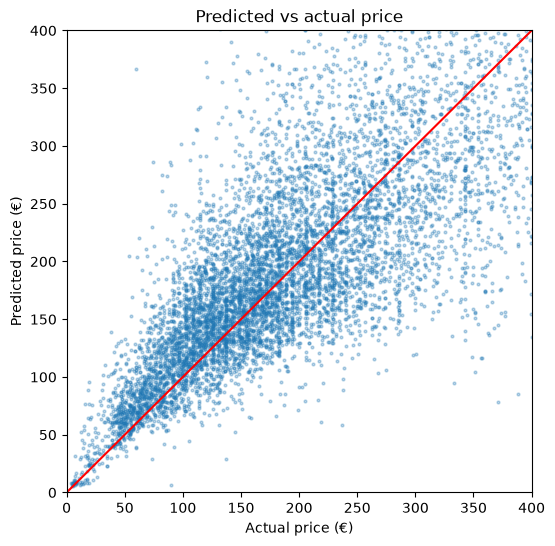

In [21]:
import matplotlib.pyplot as plt

pred = final_knn.predict(X_test[cols_B])
actual = np.expm1(y_test.values)
predicted = np.expm1(pred)
err = predicted - actual

df_err = pd.DataFrame({"actual": actual, "error": err, "abs_error": np.abs(err)})
df_err["price band"] = pd.qcut(df_err["actual"], 4,
                               labels=["cheapest 25%", "25-50%", "50-75%", "most expensive 25%"])
display(df_err.groupby("price band", observed=True).agg(
    listings=("actual", "size"), avg_price=("actual", "mean"),
    avg_error_size=("abs_error", "mean"), avg_error_direction=("error", "mean")).round(1))

plt.figure(figsize=(6, 6))
plt.scatter(actual, predicted, s=4, alpha=0.3)
plt.plot([0, 400], [0, 400], color="red")
plt.xlim(0, 400); plt.ylim(0, 400)
plt.xlabel("Actual price (€)"); plt.ylabel("Predicted price (€)")
plt.title("Predicted vs actual price")
plt.show()

**What I did:** Split the test set into four equal groups by actual price and compared the average error in euros for each. Error = predicted − actual, so positive means the model guessed too high.

| Price band | Avg price (€) | Avg error size (€) | Avg direction (€) |
|---|---|---|---|
| Cheapest 25% | 88.7 | 34.4 | +29.3 |
| 25-50% | 165.7 | 42.0 | +21.5 |
| 50-75% | 259.0 | 63.0 | +0.8 |
| Most expensive 25% | 600.4 | 187.9 | −131.5 |

**Observations:**

- The model overpredicts cheap listings and strongly underpredicts expensive ones. The middle band is balanced.
- The most expensive quarter produces about 57% of the total absolute error. In relative terms the cheapest quarter is also weak (error about 39% of price, against 24-31% for the others).
- Likely reason (hypothesis): KNN predicts a weighted average of its neighbours' prices, so predictions are pulled toward the local middle. The neighbours of a luxury listing are mostly ordinary listings of similar size in the same area, and the features contain nothing about quality, view or finish that would separate them. Listings above the 99th price percentile were also removed in preprocessing, so the model never sees the very top.
- The scatter plot is clipped at €400, so the largest underpredictions are not visible in it.

## Conclusion: KNN Regression

**Final model:** `StandardScaler` → 30 selected features (latitude and longitude always kept) → KNN with Manhattan distance, k = 10, distance weights. Validated with 5-fold CV on the training set; the test set was used only for reporting.

| Model | CV RMSE (log) | Test RMSE | Test R² | Test MAE (€) |
|---|---|---|---|---|
| 1. Baseline (k=5, Euclidean) | 0.4729 | 0.4602 | 0.635 | 93.85 |
| 2. Tuned | 0.4208 | 0.4102 | 0.710 | 85.25 |
| 3. + feature selection | 0.3945 | 0.3839 | 0.746 | 82.87 |
| 4. + forced location (final) | 0.3887 | 0.3780 | 0.754 | 81.82 |

**Why this model:** Each step improved CV error, and CV and test results agreed, so the choices were not overfit to the folds. The biggest gains came from the distance metric and weights (Experiment 2) and from removing weak features (Experiment 3). Keeping the coordinates (Experiment 4) gave only a small gain (about one fold std).

**Why KNN behaves this way:**
- It works on local similarity, so it does well on typical listings (similar size, same neighbourhood).
- It is sensitive to irrelevant features: every feature counts equally in the distance, so removing 26 weak ones cut error by about 6%. This is the curse of dimensionality.
- It averages neighbours, so it pulls extreme prices toward the middle and underpredicts luxury listings.

**Limitations:**
- Underprediction of expensive listings (average −€132 in the top quarter).
- `SelectKBest` scores features one at a time, linearly, so it can miss features that matter only in combination (it dropped latitude until I forced it in).
- Five `availability_*` columns remain in the selected features. They are correlated and may partly reflect nights already booked, so a post-booking effect is not ruled out.
- Preprocessing issues outside my model, reported to the team: median imputation before the split, and listings above the 99th price percentile removed.
- One random train/test split; KNN is also slow to predict because it stores the whole training set.
- k and the distance settings were tuned before feature selection and not re-tuned afterwards; a joint search might give a slightly different optimum.

**Possible next steps:** Predict price quantiles or model expensive listings separately; add features that describe quality; compare with the team's other models on the same split.

In [22]:
import os, time
import pandas as pd
from pathlib import Path

print("Working dir:", os.getcwd())

paths = {
    "A: ../data/processed (what the Load cell points to)": Path("../data/processed/X_train.csv"),
    "B: notebooks/ (the stray copy)": Path("X_train.csv"),
}
frames = {}
for name, p in paths.items():
    print("\n" + name)
    print("  full path:", p.resolve())
    print("  exists   :", p.exists())
    if p.exists():
        print("  modified :", time.ctime(p.stat().st_mtime))
        frames[name] = pd.read_csv(p).astype(float)
        print("  shape    :", frames[name].shape)

if len(frames) == 2:
    a, b = frames.values()
    print("\nSame columns    :", list(a.columns) == list(b.columns))
    print("Identical values:", a.equals(b))
    print("In B but not A  :", sorted(set(b.columns) - set(a.columns)))
    print("In A but not B  :", sorted(set(a.columns) - set(b.columns)))

Working dir: d:\airbnb-price-prediction\notebooks

A: ../data/processed (what the Load cell points to)
  full path: D:\airbnb-price-prediction\data\processed\X_train.csv
  exists   : True
  modified : Fri Oct  2 02:04:41 2026
  shape    : (38333, 70)

B: notebooks/ (the stray copy)
  full path: D:\airbnb-price-prediction\notebooks\X_train.csv
  exists   : True
  modified : Fri Oct  2 01:55:15 2026
  shape    : (38333, 72)

Same columns    : False
Identical values: False
In B but not A  : ['instant_bookable', 'maximum_maximum_nights']
In A but not B  : []
